# Results Analysis — All Phases

Unified analysis notebook covering every trained model across all experimental phases.


In [1]:
import wandb
wandb.login()
print("Sincronizando logs locais com o servidor do Weights & Biases...")
!wandb sync --sync-all


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/rafael/.netrc.
wandb: Currently logged in as: rafesilvadesouza (rafesilvadesouza-ufrgs) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Sincronizando logs locais com o servidor do Weights & Biases...
Find logs at: /home/rafael/Documents/alexnet_rafael/notebooks/wandb/debug-cli.rafael.log
done.
done.
Syncing: https://wandb.ai/rafesilvadesouza-ufrgs/alexnet-phase3/runs/q6hgfq8e ... done.
Syncing: https://wandb.ai/rafesilvadesouza-ufrgs/alexnet-phase3/runs/q6hgfq8e ... done.


## Configuration


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

project_root = Path.cwd().parent

PHASE_DIRS = {
    "Phase 1 — Baselines":        project_root / "results" / "baselines_qat_phase1",
    "Phase 2 — AlexNet Variants":  project_root / "results" / "alexnet_qat_phase2",
    "Phase 3 — Compensation":      project_root / "results" / "compensation_phase3",
}

WANDB_USERNAME = "rafesilvadesouza-ufrgs"
PROJECT_NAME   = "tiny-imagenet"
print(f"W&B workspace: https://wandb.ai/{WANDB_USERNAME}/{PROJECT_NAME}")

FIGURES_DIR = project_root / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

W&B workspace: https://wandb.ai/rafesilvadesouza-ufrgs/tiny-imagenet


## Load Data


In [3]:
def load_comparison_data(phase_dirs):
    """Load final_comparison.csv from each phase dir."""
    frames = []
    for label, d in phase_dirs.items():
        csv = d / "final_comparison.csv"
        if not csv.exists():
            print(f"[skip] {label}: no final_comparison.csv")
            continue
        df = pd.read_csv(csv)
        df["phase"] = label
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def load_model_summaries(phase_dirs):
    """Load per-model *_summary.json files (skips experiment_summary.json)."""
    rows = []
    for label, d in phase_dirs.items():
        for f in sorted(d.glob("*_summary.json")):
            if f.name == "experiment_summary.json":
                continue
            with open(f) as fp:
                data = json.load(fp)
            data["phase"] = label
            rows.append(data)
    return pd.DataFrame(rows) if rows else pd.DataFrame()


def load_training_histories(phase_dirs):
    """Extract fp32/qat training histories from experiment_summary.json."""
    fp32_hist, qat_hist = {}, {}
    for label, d in phase_dirs.items():
        summary = d / "experiment_summary.json"
        if not summary.exists():
            continue
        with open(summary) as f:
            data = json.load(f)
        for name, result in data.get("fp32_training_results", {}).items():
            h = result.get("history", {})
            if h and h.get("val_acc"):
                fp32_hist[f"{label}|{name}"] = {"label": name, "phase": label, **h}
        for name, result in data.get("qat_training_results", {}).items():
            h = result.get("history", {})
            if h and h.get("val_acc"):
                qat_hist[f"{label}|{name}"] = {"label": name, "phase": label, **h}
    return fp32_hist, qat_hist


df_comp   = load_comparison_data(PHASE_DIRS)
df_summ   = load_model_summaries(PHASE_DIRS)
fp32_hist, qat_hist = load_training_histories(PHASE_DIRS)

print(f"Comparison rows : {len(df_comp):3d}  (phases: {df_comp['phase'].nunique() if not df_comp.empty else 0})")
print(f"Per-model JSONs : {len(df_summ):3d}")
print(f"FP32 histories  : {len(fp32_hist):3d}   QAT histories: {len(qat_hist)}")


Comparison rows :  33  (phases: 3)
Per-model JSONs :  18
FP32 histories  :  18   QAT histories: 15


## All-Model Summary Table


In [4]:
if not df_comp.empty:
    display(df_comp.sort_values(["phase", "model"]).reset_index(drop=True))


,model,precision,top1_%,top5_%,loss,params_M,size_MB,phase
0,alexnet_tv,FP32,32.887921,58.219731,2.993848,57.823240,661.754141,Phase 1 — Baselines
1,alexnet_tv_INT8,INT8,31.903201,57.237488,3.041804,57.823240,55.332613,Phase 1 — Baselines
2,mobilenetv2,FP32,57.995582,81.514984,1.754526,2.480072,28.751925,Phase 1 — Baselines
3,resnet18_tv,FP32,53.913635,77.797484,1.965944,11.279112,129.208681,Phase 1 — Baselines
4,vgg_style,FP32,51.814806,75.881696,2.070006,2.405288,27.584812,Phase 1 — Baselines
5,vgg_style_INT8,INT8,51.188743,75.520074,2.093931,2.405288,2.376703,Phase 1 — Baselines
6,alexnet_2x2,FP32,30.023813,55.553859,3.162072,1.052744,12.062769,Phase 2 — AlexNet Variants
7,alexnet_2x2_INT8,INT8,30.888581,56.483012,3.104258,1.052744,1.039989,Phase 2 — AlexNet Variants
8,alexnet_3x3,FP32,35.787162,61.282206,2.884496,57.605128,659.258051,Phase 2 — AlexNet Variants
9,alexnet_3x3_INT8,INT8,36.190116,61.982745,2.861196,57.605128,55.124596,Phase 2 — AlexNet Variants


## Visualizations


In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11})

phases = list(PHASE_DIRS.keys())
_tab10 = plt.cm.tab10.colors
PHASE_COLORS = {p: _tab10[i] for i, p in enumerate(phases)}


### 1. FP32 Accuracy — All Models


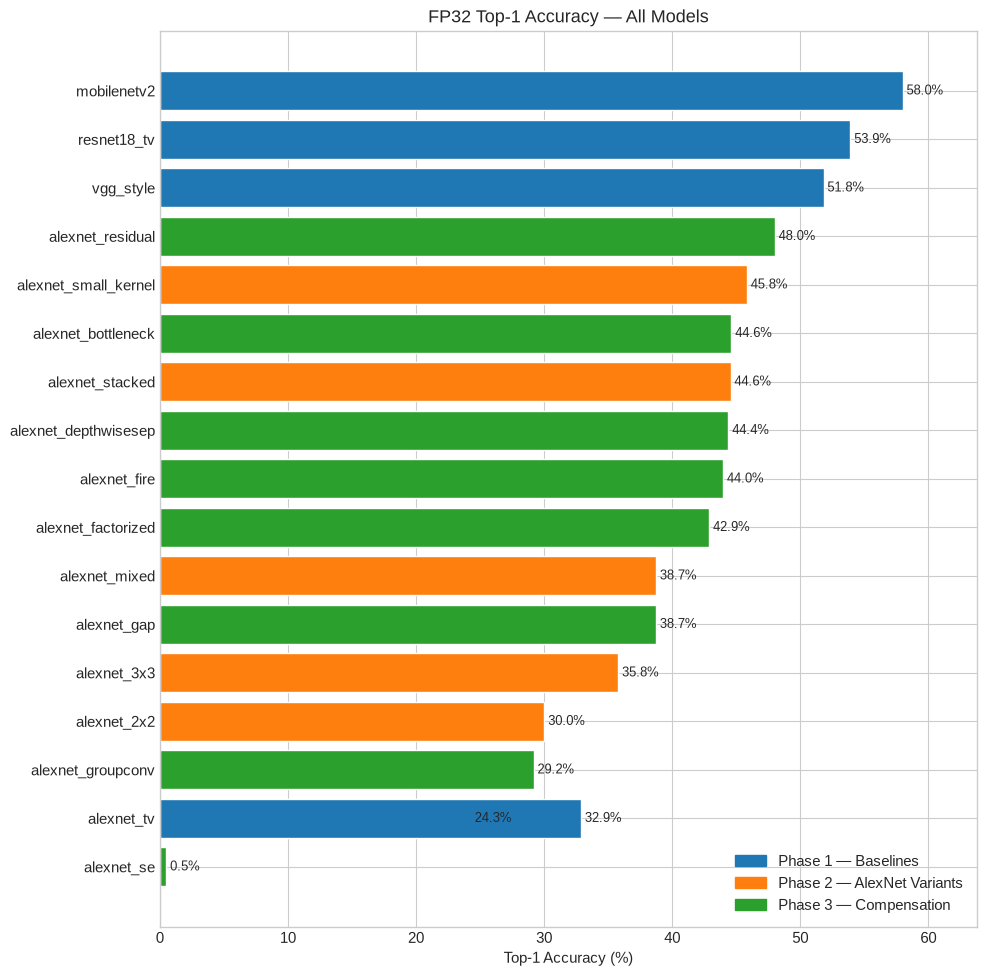

In [6]:
df_fp32 = df_comp[df_comp["precision"] == "FP32"].copy()

if df_fp32.empty:
    print("[skip] No FP32 data available")
else:
    df_fp32 = df_fp32.sort_values("top1_%", ascending=True).reset_index(drop=True)
    colors = [PHASE_COLORS[p] for p in df_fp32["phase"]]

    fig, ax = plt.subplots(figsize=(10, max(5, len(df_fp32) * 0.55)))
    bars = ax.barh(df_fp32["model"], df_fp32["top1_%"], color=colors, edgecolor="white")

    for bar, val in zip(bars, df_fp32["top1_%"]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=9)

    ax.set_xlabel("Top-1 Accuracy (%)")
    ax.set_title("FP32 Top-1 Accuracy — All Models")

    handles = [mpatches.Patch(color=PHASE_COLORS[p], label=p)
               for p in phases if p in df_fp32["phase"].values]
    ax.legend(handles=handles, loc="lower right")
    ax.set_xlim(0, df_fp32["top1_%"].max() * 1.1)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fp32_accuracy_bar.png", dpi=150, bbox_inches="tight")
    plt.show()


### 2. FP32 vs INT8 Quantization Impact


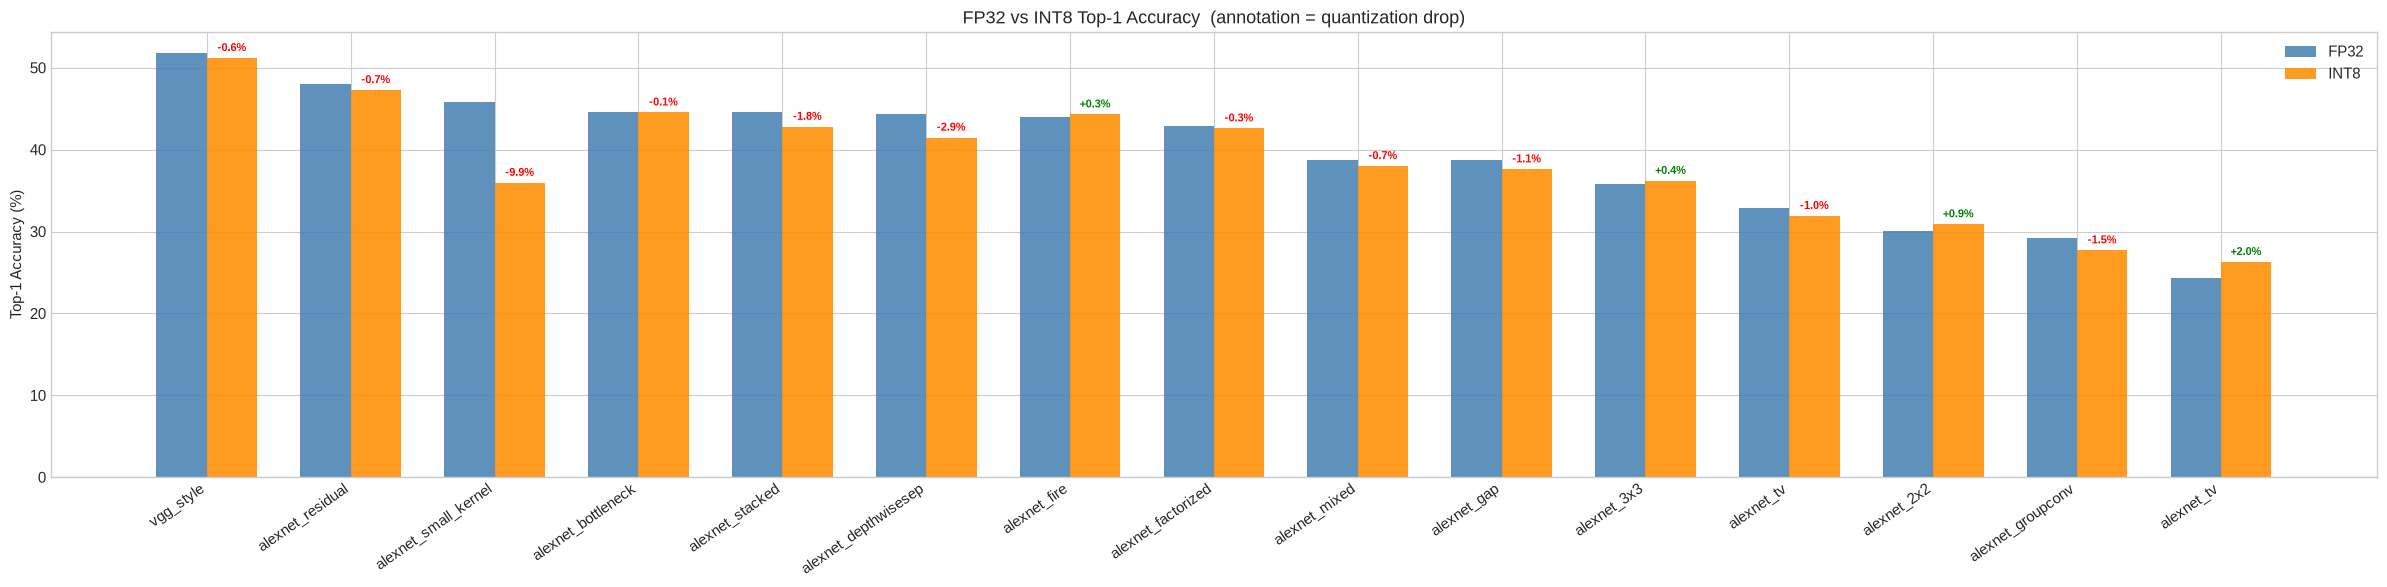

In [7]:
_df = df_comp.copy()
_df["base_model"] = _df["model"].str.replace("_INT8", "", regex=False)

has_both = _df.groupby("base_model")["precision"].apply(
    lambda x: {"FP32", "INT8"}.issubset(set(x))
)
paired = has_both[has_both].index.tolist()

if not paired:
    print("[skip] No models with both FP32 and INT8 — rerun QAT notebooks first")
else:
    df_paired = _df[_df["base_model"].isin(paired)].copy()
    df_pivot = (
        df_paired
        .pivot_table(index=["base_model", "phase"], columns="precision", values="top1_%")
        .reset_index()
    )
    df_pivot["drop"] = df_pivot["FP32"] - df_pivot["INT8"]
    df_pivot = df_pivot.sort_values("FP32", ascending=False).reset_index(drop=True)

    x = np.arange(len(df_pivot))
    w = 0.35

    fig, ax = plt.subplots(figsize=(max(10, len(df_pivot) * 1.6), 6))
    ax.bar(x - w / 2, df_pivot["FP32"], w, label="FP32", color="steelblue", alpha=0.87)
    ax.bar(x + w / 2, df_pivot["INT8"], w, label="INT8", color="darkorange", alpha=0.87)

    for i, row in df_pivot.iterrows():
        color = "red" if row["drop"] > 0 else "green"
        sign  = "-" if row["drop"] > 0 else "+"
        ax.annotate(
            f"{sign}{abs(row['drop']):.1f}%",
            xy=(x[i] + w / 2, row["INT8"]),
            xytext=(0, 5), textcoords="offset points",
            ha="center", fontsize=8, color=color, fontweight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(df_pivot["base_model"], rotation=35, ha="right")
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title("FP32 vs INT8 Top-1 Accuracy  (annotation = quantization drop)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fp32_vs_int8_bar.png", dpi=150, bbox_inches="tight")
    plt.show()


### 3. Accuracy vs Model Size


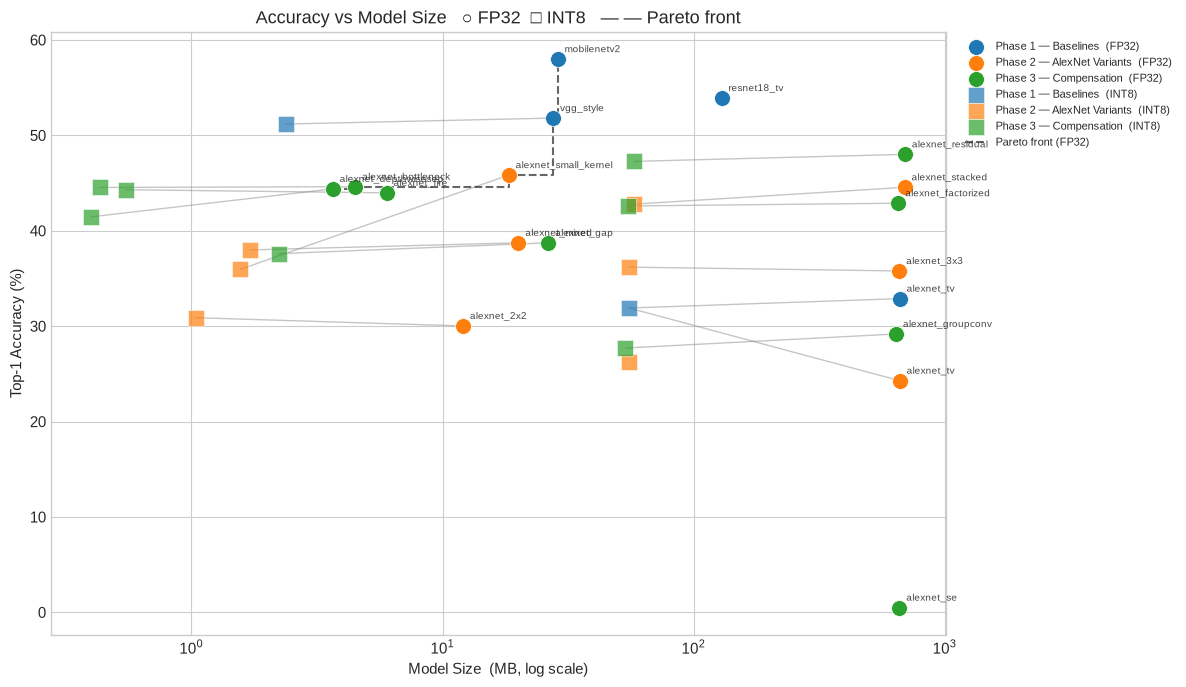

In [8]:
def pareto_front_mask(xs, ys):
    """Boolean mask: True if point is Pareto-optimal (minimize x, maximize y)."""
    xs, ys = np.asarray(xs, float), np.asarray(ys, float)
    dominated = np.zeros(len(xs), dtype=bool)
    for i in range(len(xs)):
        for j in range(len(xs)):
            if i != j and xs[j] <= xs[i] and ys[j] >= ys[i] and (xs[j] < xs[i] or ys[j] > ys[i]):
                dominated[i] = True
                break
    return ~dominated


df_fp32_sc = df_comp[df_comp["precision"] == "FP32"].copy()
df_int8_sc = df_comp[df_comp["precision"] == "INT8"].copy()
df_int8_sc["base_model"] = df_int8_sc["model"].str.replace("_INT8", "", regex=False)

if df_fp32_sc.empty:
    print("[skip] No FP32 data for scatter")
else:
    fig, ax = plt.subplots(figsize=(12, 7))

    # FP32 → INT8 connector lines
    for _, row in df_fp32_sc.iterrows():
        match = df_int8_sc[df_int8_sc["base_model"] == row["model"]]
        if not match.empty:
            ir = match.iloc[0]
            ax.plot([row["size_MB"], ir["size_MB"]], [row["top1_%"], ir["top1_%"]],
                    color="gray", lw=1, alpha=0.45, zorder=1)

    # FP32 scatter
    for phase in phases:
        sub = df_fp32_sc[df_fp32_sc["phase"] == phase]
        if sub.empty: continue
        ax.scatter(sub["size_MB"], sub["top1_%"],
                   c=[PHASE_COLORS[phase]], marker="o", s=130,
                   label=f"{phase}  (FP32)", zorder=3, edgecolors="white", lw=0.5)

    # INT8 scatter
    for phase in phases:
        sub = df_int8_sc[df_int8_sc["phase"] == phase]
        if sub.empty: continue
        ax.scatter(sub["size_MB"], sub["top1_%"],
                   c=[PHASE_COLORS[phase]], marker="s", s=130,
                   label=f"{phase}  (INT8)", zorder=3, edgecolors="white", lw=0.5, alpha=0.7)

    # Pareto front (FP32)
    if len(df_fp32_sc) >= 2:
        pf_mask = pareto_front_mask(df_fp32_sc["size_MB"].values, df_fp32_sc["top1_%"].values)
        pf = df_fp32_sc[pf_mask].sort_values("size_MB")
        ax.step(pf["size_MB"], pf["top1_%"], where="post",
                color="black", lw=1.5, ls="--", alpha=0.6, label="Pareto front (FP32)", zorder=2)

    # Labels
    for _, row in df_fp32_sc.iterrows():
        ax.annotate(row["model"], (row["size_MB"], row["top1_%"]),
                    xytext=(5, 5), textcoords="offset points", fontsize=7.5, alpha=0.85)

    ax.set_xscale("log")
    ax.set_xlabel("Model Size  (MB, log scale)")
    ax.set_ylabel("Top-1 Accuracy (%)")
    ax.set_title("Accuracy vs Model Size   ○ FP32  □ INT8   — — Pareto front")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "accuracy_vs_size.png", dpi=150, bbox_inches="tight")
    plt.show()


### 4. Accuracy vs Compute (MACs)


/tmp/ipykernel_776306/886232536.py:23: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_776306/886232536.py:24: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  plt.savefig(FIGURES_DIR / "accuracy_vs_macs.png", dpi=150, bbox_inches="tight")
/home/rafael/Documents/alexnet_rafael/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


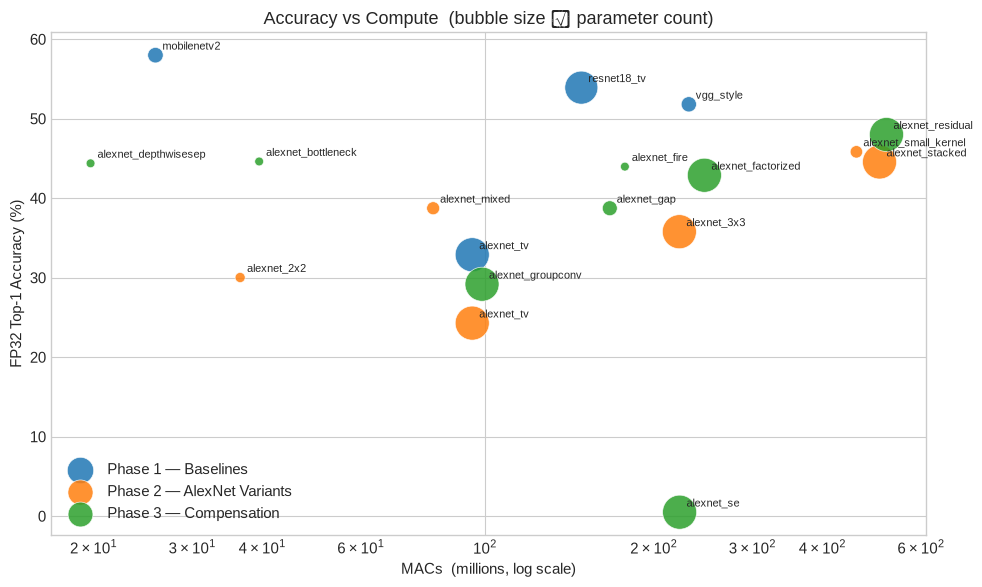

In [9]:
if df_summ.empty or "macs" not in df_summ.columns or df_summ["macs"].dropna().empty:
    print("[skip] No MACs data in per-model summaries")
else:
    df_macs = df_summ[df_summ["macs"].notna() & df_summ["fp32_top1"].notna()].copy()
    df_macs["macs_M"] = df_macs["macs"] / 1e6

    fig, ax = plt.subplots(figsize=(10, 6))
    for phase in df_macs["phase"].unique():
        sub = df_macs[df_macs["phase"] == phase]
        sizes = (sub["params_m"].fillna(1) * 50).clip(40, 600)
        ax.scatter(sub["macs_M"], sub["fp32_top1"],
                   c=[PHASE_COLORS.get(phase, "gray")], s=sizes,
                   label=phase, alpha=0.85, edgecolors="white", lw=0.5)
        for _, row in sub.iterrows():
            ax.annotate(row["model_name"], (row["macs_M"], row["fp32_top1"]),
                        xytext=(5, 4), textcoords="offset points", fontsize=8)

    ax.set_xscale("log")
    ax.set_xlabel("MACs  (millions, log scale)")
    ax.set_ylabel("FP32 Top-1 Accuracy (%)")
    ax.set_title("Accuracy vs Compute  (bubble size ∝ parameter count)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "accuracy_vs_macs.png", dpi=150, bbox_inches="tight")
    plt.show()


### 5. Inference Latency


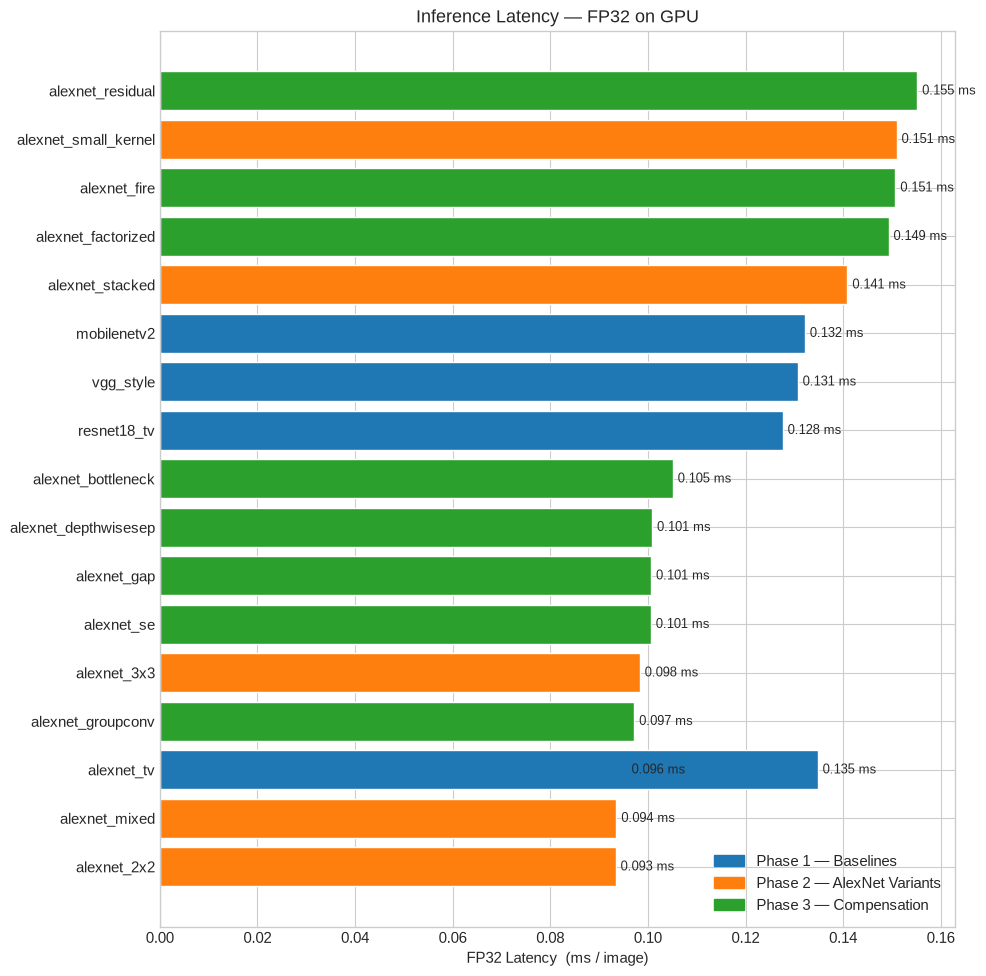

In [10]:
_lat_col = "fp32_latency_ms_per_image"
if df_summ.empty or _lat_col not in df_summ.columns or df_summ[_lat_col].dropna().empty:
    print("[skip] No latency data available")
else:
    df_lat = df_summ[df_summ[_lat_col].notna()].sort_values(_lat_col).copy()
    colors = [PHASE_COLORS.get(p, "gray") for p in df_lat["phase"]]

    fig, ax = plt.subplots(figsize=(10, max(4, len(df_lat) * 0.55)))
    bars = ax.barh(df_lat["model_name"], df_lat[_lat_col], color=colors, edgecolor="white")

    for bar, val in zip(bars, df_lat[_lat_col]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f} ms", va="center", fontsize=9)

    ax.set_xlabel("FP32 Latency  (ms / image)")
    ax.set_title("Inference Latency — FP32 on GPU")

    handles = [mpatches.Patch(color=PHASE_COLORS[p], label=p)
               for p in phases if p in df_lat["phase"].values]
    ax.legend(handles=handles)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "latency_bar.png", dpi=150, bbox_inches="tight")
    plt.show()


### 6–7. Training Curves

One subplot per model. Lines: **val Top-1** (solid), **train Top-1** (dashed), **val Top-5** (dotted).


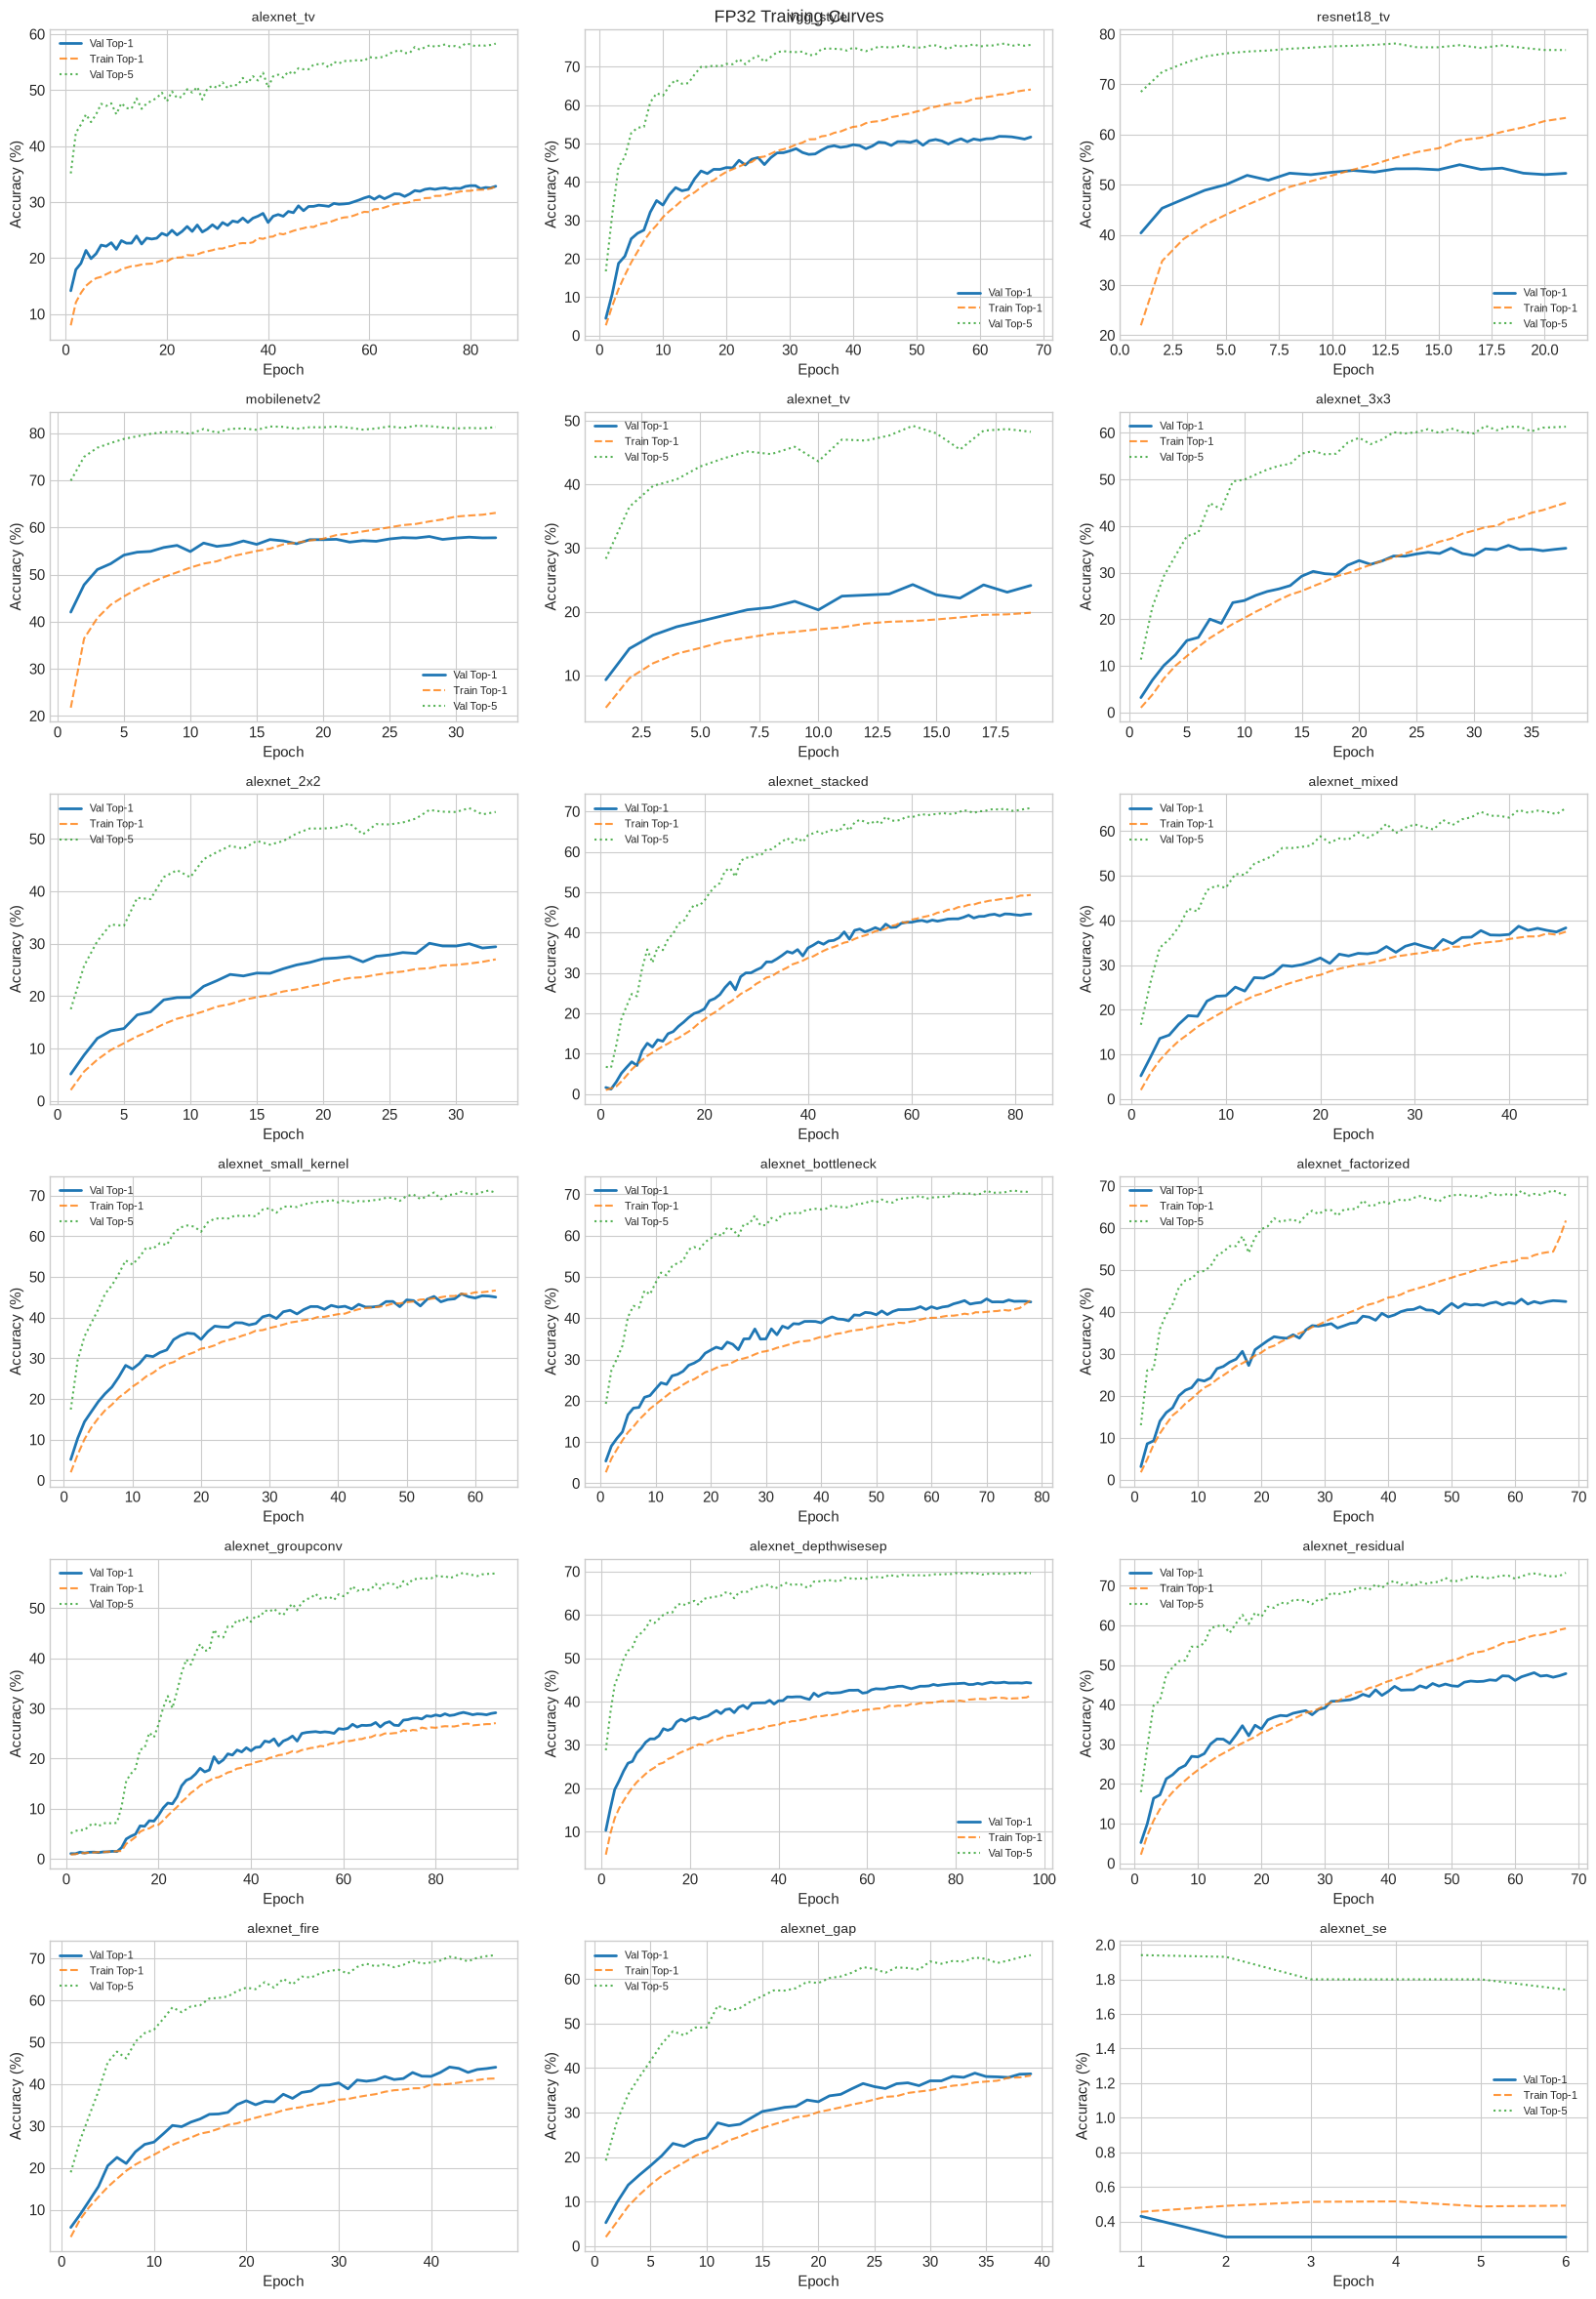

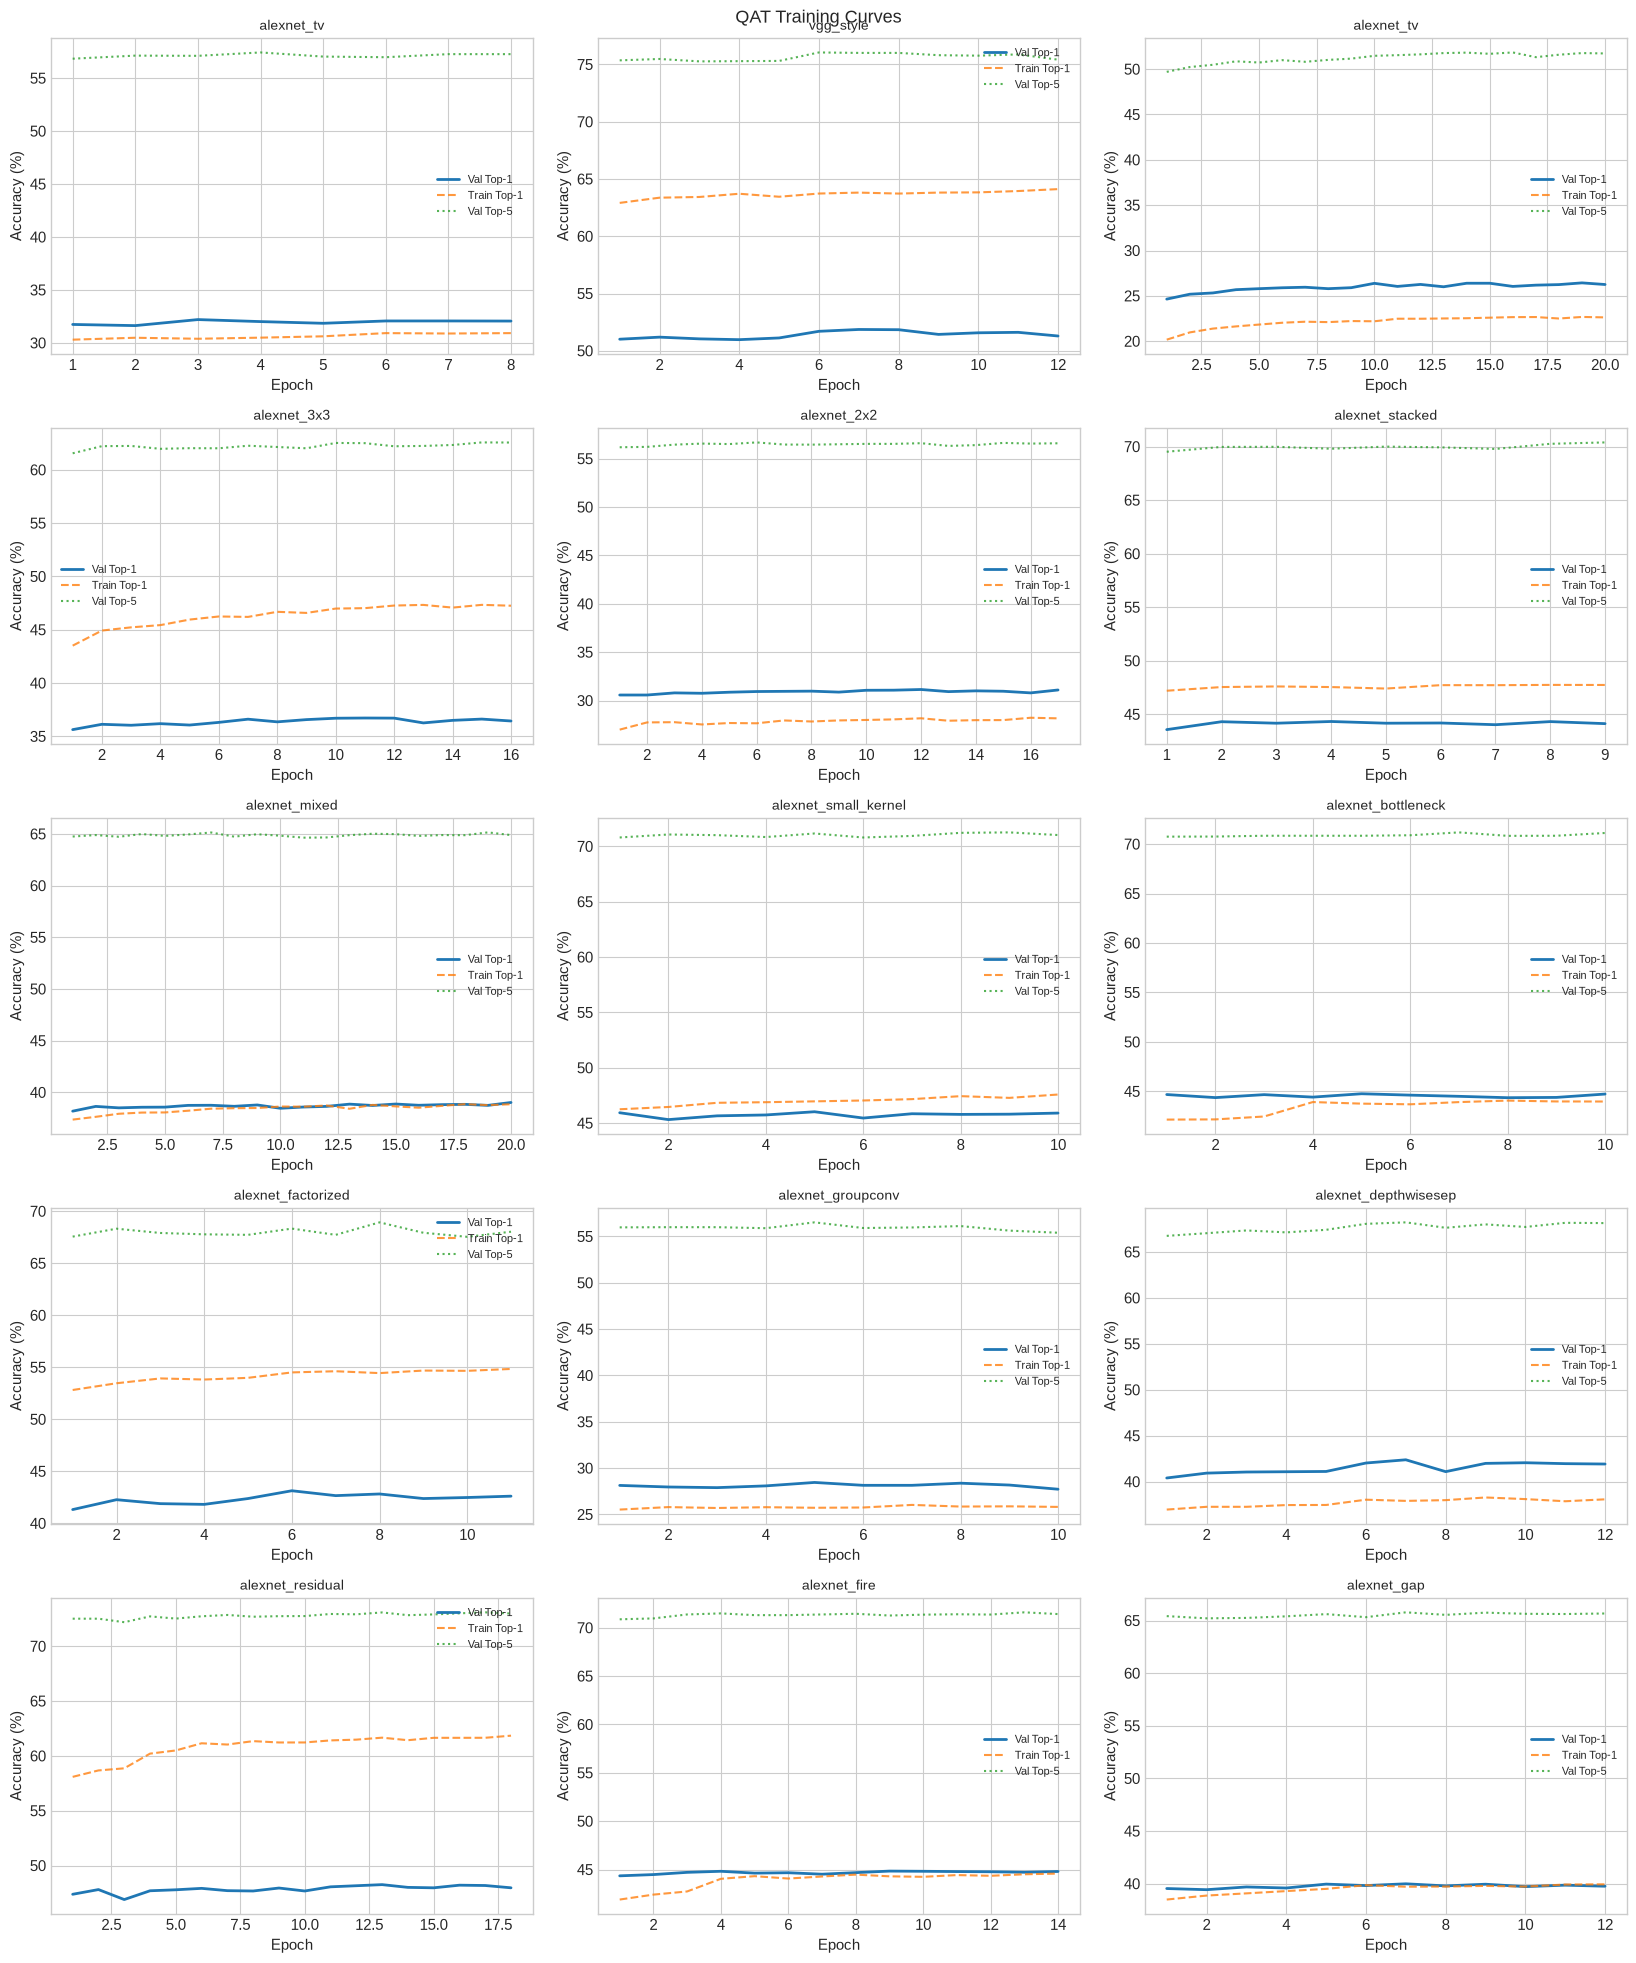

In [11]:
def plot_training_curves(histories, title_prefix):
    if not histories:
        print(f"[skip] No {title_prefix} training histories available")
        return

    items = list(histories.items())
    n = len(items)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 4), squeeze=False)

    for idx, (_, h) in enumerate(items):
        ax = axes[idx // ncols][idx % ncols]
        epochs = range(1, len(h["val_acc"]) + 1)

        ax.plot(epochs, h["val_acc"],   label="Val Top-1",  lw=2.0)
        if "train_acc" in h:
            ax.plot(epochs, h["train_acc"], label="Train Top-1", lw=1.5, ls="--", alpha=0.8)
        if "val_top5" in h:
            ax.plot(epochs, h["val_top5"], label="Val Top-5",  lw=1.5, ls=":",  alpha=0.8)

        ax.set_title(h["label"], fontsize=10)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy (%)")
        ax.legend(fontsize=8)

    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(f"{title_prefix} Training Curves", fontsize=13)
    plt.tight_layout()
    fname = title_prefix.lower().replace(" ", "_") + "_training_curves.png"
    plt.savefig(FIGURES_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()


plot_training_curves(fp32_hist, "FP32")
plot_training_curves(qat_hist,  "QAT")


## Condensed Results — Master CSV Exports

Export all results to easy-to-parse CSV files in `results/` for analysis outside the notebook.

In [12]:
### results.csv — Comparison table with quantization impact

df_results = df_comp.copy()

# Strip _INT8 suffix to match FP32 base models
df_results["base_model"] = df_results["model"].str.replace("_INT8", "", regex=False)

# Pivot to get FP32 and INT8 side-by-side
df_pivot = (
    df_results
    .pivot_table(
        index=["base_model", "phase"],
        columns="precision",
        values=["top1_%", "top5_%", "loss", "params_M", "size_MB"],
        aggfunc="first"
    )
    .reset_index()
)

# Flatten multi-level columns
df_pivot.columns = ["_".join(col).strip("_") if col[1] else col[0] for col in df_pivot.columns]

# Compute quantization drops (positive = drop, negative = gain)
if "top1_%_FP32" in df_pivot.columns and "top1_%_INT8" in df_pivot.columns:
    df_pivot["qat_top1_drop_%"] = df_pivot["top1_%_FP32"] - df_pivot["top1_%_INT8"]
if "top5_%_FP32" in df_pivot.columns and "top5_%_INT8" in df_pivot.columns:
    df_pivot["qat_top5_drop_%"] = df_pivot["top5_%_FP32"] - df_pivot["top5_%_INT8"]

# Reorder columns for readability
cols_order = [
    "phase", "base_model",
    "top1_%_FP32", "top1_%_INT8", "qat_top1_drop_%",
    "top5_%_FP32", "top5_%_INT8", "qat_top5_drop_%",
    "loss_FP32", "loss_INT8",
    "params_M_FP32", "size_MB_FP32", "size_MB_INT8"
]
cols_order = [c for c in cols_order if c in df_pivot.columns]
df_results_final = df_pivot[cols_order].sort_values(["phase", "top1_%_FP32"], ascending=[True, False])

# Save to results/
results_csv_path = project_root / "results" / "results.csv"
df_results_final.to_csv(results_csv_path, index=False)
print(f"✓ Saved {len(df_results_final)} rows → {results_csv_path}")
display(df_results_final)

✓ Saved 18 rows → /home/rafael/Documents/alexnet_rafael/results/results.csv


,phase,base_model,top1_%_FP32,top1_%_INT8,qat_top1_drop_%,top5_%_FP32,top5_%_INT8,qat_top5_drop_%,loss_FP32,loss_INT8,params_M_FP32,size_MB_FP32,size_MB_INT8
15,Phase 1 — Baselines,mobilenetv2,57.995582,NaN,NaN,81.514984,NaN,NaN,1.754526,NaN,2.480072,28.751925,NaN
16,Phase 1 — Baselines,resnet18_tv,53.913635,NaN,NaN,77.797484,NaN,NaN,1.965944,NaN,11.279112,129.208681,NaN
17,Phase 1 — Baselines,vgg_style,51.814806,51.188743,0.626063,75.881696,75.520074,0.361621,2.070006,2.093931,2.405288,27.584812,2.376703
13,Phase 1 — Baselines,alexnet_tv,32.887921,31.903201,0.984719,58.219731,57.237488,0.982243,2.993848,3.041804,57.823240,661.754141,55.332613
11,Phase 2 — AlexNet Variants,alexnet_small_kernel,45.836565,35.946080,9.890485,71.076936,61.607319,9.469616,2.349307,3.119788,1.602376,18.353315,1.561041
12,Phase 2 — AlexNet Variants,alexnet_stacked,44.559684,42.792845,1.766840,70.791721,68.714178,2.077544,2.386047,2.470658,60.483976,692.254669,57.941553
8,Phase 2 — AlexNet Variants,alexnet_mixed,38.740057,37.993860,0.746197,64.825773,63.802063,1.023710,2.683706,2.724205,1.750024,20.042604,1.705048
1,Phase 2 — AlexNet Variants,alexnet_3x3,35.787162,36.190116,-0.402954,61.282206,61.982745,-0.700539,2.884496,2.861196,57.605128,659.258051,55.124596
0,Phase 2 — AlexNet Variants,alexnet_2x2,30.023813,30.888581,-0.864768,55.553859,56.483012,-0.929153,3.162072,3.104258,1.052744,12.062769,1.039989
14,Phase 2 — AlexNet Variants,alexnet_tv,24.288143,26.276261,-1.988117,49.215373,51.752245,-2.536872,3.438936,3.302015,57.823240,661.754141,55.332613


In [13]:
### model_details.csv — Flattened per-model summary metrics

# Load all per-model summary JSONs and flatten into one row per model
detailed_rows = []
for label, phase_dir in PHASE_DIRS.items():
    for json_file in sorted(phase_dir.glob("*_summary.json")):
        if json_file.name == "experiment_summary.json":
            continue
        with open(json_file) as f:
            data = json.load(f)
        row = {"phase": label}
        
        # Flatten dict recursively (one level deep)
        def flatten_dict(d, parent_key=''):
            items = []
            for k, v in d.items():
                if k == "phase":
                    continue
                new_key = f"{parent_key}_{k}" if parent_key else k
                if isinstance(v, dict):
                    items.extend(flatten_dict(v, new_key).items())
                elif isinstance(v, (list, tuple)):
                    items.append((new_key, str(v)))
                else:
                    items.append((new_key, v))
            return dict(items)
        
        row.update(flatten_dict(data))
        detailed_rows.append(row)

df_details = pd.DataFrame(detailed_rows)

# Reorder columns: phase and model_name first, then others
cols_priority = ["phase", "model_name"]
cols_rest = sorted([c for c in df_details.columns if c not in cols_priority])
df_details_reordered = df_details[cols_priority + cols_rest]

# Save
details_csv_path = project_root / "results" / "model_details.csv"
df_details_reordered.to_csv(details_csv_path, index=False)
print(f"✓ Saved {len(df_details_reordered)} rows, {len(df_details_reordered.columns)} columns → {details_csv_path}")
print(f"\nColumns: {', '.join(df_details_reordered.columns[:15])}...")
display(df_details_reordered[[c for c in ["phase", "model_name", "fp32_top1", "int8_top1", "params_m", "macs", "fp32_latency_ms_per_image"] if c in df_details_reordered.columns]].head(10))

✓ Saved 18 rows, 33 columns → /home/rafael/Documents/alexnet_rafael/results/model_details.csv

Columns: phase, model_name, avg_epoch_time_s, best_val_loss, best_val_top1, best_val_top5, compression_ratio, epochs, final_train_loss, final_val_top1, final_val_top5, flops, fp32_latency_ms_per_image, fp32_loss, fp32_size_mb...


,phase,model_name,fp32_top1,int8_top1,params_m,macs,fp32_latency_ms_per_image
0,Phase 1 — Baselines,alexnet_tv,32.887921,31.903201,57.823240,94868416,0.134806
1,Phase 1 — Baselines,mobilenetv2,57.995582,NaN,2.480072,25799936,0.132181
2,Phase 1 — Baselines,resnet18_tv,53.913635,NaN,11.279112,148555776,0.127640
3,Phase 1 — Baselines,vgg_style,51.814806,51.188743,2.405288,231086080,0.130711
4,Phase 2 — AlexNet Variants,alexnet_2x2,30.023813,30.888581,1.052744,36542464,0.093406
5,Phase 2 — AlexNet Variants,alexnet_3x3,35.787162,36.190116,57.605128,222281728,0.098346
6,Phase 2 — AlexNet Variants,alexnet_mixed,38.740057,37.993860,1.750024,80792576,0.093557
7,Phase 2 — AlexNet Variants,alexnet_small_kernel,45.836565,35.946080,1.602376,460179456,0.150975
8,Phase 2 — AlexNet Variants,alexnet_stacked,44.559684,42.792845,60.483976,506085376,0.140897
9,Phase 2 — AlexNet Variants,alexnet_tv,24.288143,26.276261,57.823240,94868416,0.095660
